# 3장 1강: 편향-분산 트레이드오프와 과적합/과소적합 진단

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 모델 복잡도와 과적합/과소적합의 관계를 확인합니다.

- 모델이 너무 단순할 때 나타나는 **고편향(과소적합)** 상태를 확인합니다.
- 모델이 너무 복잡할 때 나타나는 **고분산(과적합)** 상태를 확인합니다.
- `learning_curve()`를 이용하여 학습곡선을 확인합니다.
- `validation_curve()`를 이용하여 모델 복잡도에 따른 Train / Validation 성능 변화를 확인합니다.
- `train-valid gap`을 이용하여 모델 상태를 진단합니다.
- 진단 결과에 맞는 대응 전략을 선택합니다.

> 이 실습에서는 3장 1강 교안에서 다룬 편향-분산, 학습곡선, 검증곡선, train-valid gap, 과적합/과소적합 대응 전략만 사용합니다.

In [2]:

# 편향(bias) : 학습 데이터를 바꾸어 여러번 생성한 모델의 평균적인 예측이 실제 관측에서 체계적으로 벗어나는 정도
# → 실제 매출이 광고비에 따라 비선형 형태로 변하는데
# → 선형 회귀를 사용하여 직선 하나로만 예측을 한다고 가정해보면
# → 고객 데이터를 바꾸어도 비슷한 구간에서 지속적으로 틀린다면 편향을 고려해볼 수 있다.

# 분산(variance) : 학습 데이터가 바뀌었을 때 같은 입력에 대한 모델 예측이 달라지는 정도
# → 성별, 목소리 → 2가지 힌트를 가지고 DS반의 영준님을 특정할 수 있다.
# → 성별, 목소리, ai역량평가 1차, 2차, 키, 생일 → 6가지 힌트를 가지고 DS반의 영준님을 특정할 수 있다.

# 과소적합 : 모델이 학습 데이터의 패턴을 충분하게 파악하지 못함
# → 보통 decision tree에서 트리 깊이를 1정도로하여 충분한 패턴을 학습하지 못할 때에 발생할 수 있다.
# 행 수와 컬럼을 늘려서 해결하고자 함

# 과적합 : 모델이 학습의 우연한 패턴까지 학습하여 새로운 데이터에 대한 적응력이 떨어짐
# → 사탕 : 포도맛, 망고맛, 콜라맛, 레몬맛
# → 모델이 0.1 = 포도맛이라고 정답을 외워버리는 경우
# → 새롭게 포도맛(0.15)가 추가되면 못맞추게 되어버리는 경우

# 노이즈 : 패턴이 없이 우연한 변동이나 측정 오차가 있는 경우
# → 평상시에 구매가 없던 A고객이 갑자기 구매하는 경우
# → 1월 온도가 한 낮 20도까지 오른 경우
# 이상치인지 아닌지 잘 모르겠을 때 일단 노이즈 처리 시키기도 함

# 하이퍼 파라미터 : 학습 방법이나 모델의 구조를 정하기 위해 설정하는 값
# → epoch, learning rate 등의 비율을 설정
# 하이퍼 파라미터 튜닝 : 여러 설정값의 후보를 통해 좋은 성능을 찾는 과정
# → epoch(학습횟수) : 1 / 10 / -> 5
# → learning rate(학습률) : 23 / 2.4 -> 6
# → 모델의 성능을 더 높이기 위해서 학습률이나 학습횟수 등을 바꾸어
# → 결과를 더 높이는 최적의 모델을 찾으려는 과정

# 규제(regularization) : 모델이 데이터에 지나치게 맞추어 결과를 내지 않도록 학습에 제약을 주는 방법
# → 사탕 : 포도맛, 망고맛, 콜라맛, 레몬맛
# 신 정도 : 0.1, 0.4, 0.05, 0.7
# → 모델이 0.1 = 포도맛이라고 정답을 외워버리는 경우 → 정답률이 100%라면 굳이 다른 힌트를 보지 않고 안바꿈
# → 100% → 신 정도만 보고 포도맛이라는걸 예측했다면 다른 컬럼은 무의미해짐
# → 모델에 대한 해석이 떨어질 가능성이 있음

# 학습곡선 : 학습 성능과 검증 성능을 학습하는 변화에 따라 그 변화를 그래프로 나타낸 값 
# → 모의고사 공부시간을 늘릴 때마다 10점씩 상승했고
# → 실전 모의고사 공부를 해보니 10점씩 상승했다.

## 실습 환경 / 데이터

- Python
- pandas
- numpy
- matplotlib
- scikit-learn
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 여러 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

이번 강의의 목적은 예측 성능 자체를 최대화하는 것이 아니라 **모델 복잡도에 따라 Train / Validation 성능이 어떻게 달라지는지 진단하는 것**입니다.

### 사용할 특성

결측치 처리 자체가 이번 강의의 학습 목표가 아니므로, 결측치가 없는 숫자형 특성 중 일부만 사용합니다.

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `TotalBsmtSF`
- `1stFlrSF`
- `YearBuilt`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 특성과 예측 대상을 선택합니다.
3. 결측치가 없는지 확인합니다.
4. 데이터 크기와 기초 통계량을 확인합니다.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve, validation_curve

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

X = house[features]
y = house["SalePrice"]

print("X 크기:", X.shape)
print("y 크기:", y.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

print("\n[기초 통계량]")
display(X.describe())

X 크기: (1460, 6)
y 크기: (1460,)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0



[기초 통계량]


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1162.626712,1971.267808
std,1.382997,525.480383,0.747315,438.705324,386.587738,30.202904
min,1.000000,334.000000,0.000000,0.000000,334.000000,1872.000000
25%,5.000000,1129.500000,1.000000,795.750000,882.000000,1954.000000
50%,6.000000,1464.000000,2.000000,991.500000,1087.000000,1973.000000
75%,7.000000,1776.750000,2.000000,1298.250000,1391.250000,2000.000000
max,10.000000,5642.000000,4.000000,6110.000000,4692.000000,2010.000000


---

# 필수 1. 학습곡선으로 과소적합과 과적합 진단

## 배경

학습곡선은 **학습 데이터의 양을 늘려가며 Train score와 Validation score가 어떻게 변하는지 확인하는 그래프**입니다.

이번 문제에서는 같은 Ames Housing 데이터에 대해 두 개의 결정트리를 비교합니다.

- `max_depth=2` → 복잡도가 낮은 모델
- `max_depth=None` → 깊이를 제한하지 않은 복잡한 모델

## 문제 1. `max_depth=2` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=2, random_state=42)`를 만듭니다.
2. `learning_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 학습 데이터 비율은 `np.linspace(0.1, 1.0, 6)`을 사용합니다.
5. 각 구간의 Train score와 Validation score 평균을 계산합니다.
6. 두 점수를 하나의 그래프에 표시합니다.
7. 두 곡선이 어디에서 수렴하는지 확인합니다.

### 확인 포인트

- 두 점수가 모두 낮은 수준에서 가까워지는가?
- 모델이 너무 단순한 상태인지 판단할 수 있는가?

,train_size,train_score,val_score,gap
0,116,0.702,0.578,0.124
1,327,0.670,0.600,0.069
2,537,0.665,0.594,0.071
3,747,0.653,0.601,0.053
4,957,0.646,0.574,0.071
5,1168,0.634,0.602,0.032


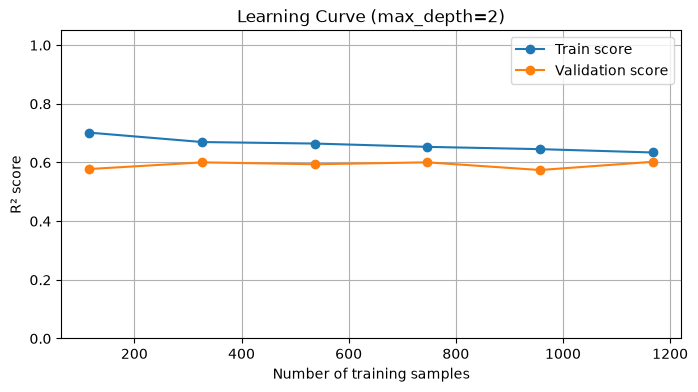

In [4]:
# TODO
# max_depth=2 결정트리의 학습곡선을 그려보세요.

# 1. 복잡도가 낮은 결정트리
tree_shallow = DecisionTreeRegressor(max_depth=2, random_state=42)

# 2~4. 학습 데이터 양을 늘려 가며 5-fold 교차검증
train_sizes, train_scores, val_scores = learning_curve(
    tree_shallow,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

# 5. 구간별 5개 fold 점수의 평균
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

shallow_result = pd.DataFrame({
    "train_size": train_sizes,
    "train_score": train_mean,
    "val_score": val_mean,
    "gap": train_mean - val_mean
}).round(3)
display(shallow_result)

# 6. 두 점수를 하나의 그래프에
plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, marker="o", label="Train score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
plt.title("Learning Curve (max_depth=2)")
plt.xlabel("Number of training samples")
plt.ylabel("R² score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

R² : 결정계수 (설명력)  
R² = 1 : 실제값과 예측값이 일치  
R² = 0 : 실제 평균만 예측, 충분히 설명하지 못함  
R²이 1에 가까울수록 모델이 그만큼 데이터에 대한 설명력을 가지고 있다  

- 학습샘플 수 116 : train R²의 평균 0.70 / validation R²의 평균 0.57  
-> 판단 : 적은 학습데이터에서  비교적 차이가 큼 (0.13)

- 학습샘플 수 327 : train R²의 평균 0.66 / validation R²의 평균 0.60   
-> 판단 : train 데이터의 R²은 0.04 감소 validation R²은 0.03 상승  
-> 격차가 줄어들었다.  

- 학습샘플 수 537 : train R²의 평균 0.66 / validation R²의 평균 0.59  
-> 판단 : train R²은 유지 validation R²은 0.01 감소  

- 학습샘플 수 1,168 : train R²의 평균 0.63 / validation R²의 평균 0.60  
-> 판단 : 평균점수 차이가 가장 낮다.  

`그렇다면 이 표와 그래프를 보고 과소적합 또는 편향의 신호를 알 수 있는가?`  
-> R²값이 train과 validation에서 약 0.60정도, 즉 데이터에 대한 파악이 약 60점 정도라고 보인다.  
-> R²값이 **비교적** 0.60으로 낮기 때문에 모델이 해당 데이터에 대한 충분한 파악을 하지 못한 과소적합을 의심해볼 수 있음.  
단, 'R²가 0.60이면 무조건 낮다'는 기준이 없기 때문에 추후 다른 평가지표나 그래프를 통해 근거를 강화해야함.  

해석 : 깊이 2의 결정틑리는 최대 fold의 학습크기 1,168개에서 train R² : 0.63, validation R² : 0.60  
-> 두 점수의 차이는 1,168에서 격차가 가장 작았지만 R²이 낮아 과소적합을 의심해야한다.  


### Q1. `max_depth=2` 모델은 과소적합과 과적합 중 어느 쪽에 더 가깝다고 볼 수 있나요?

**답변:**  
-> 과소적합에 더 가까움 train과 validation의 R²값이 모두 낮았으며 그 간격도 적었다.

## 문제 2. `max_depth=None` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=None, random_state=42)`를 만듭니다.
2. 필수 1 문제 1과 동일한 방식으로 `learning_curve()`를 사용합니다.
3. Train score와 Validation score를 그래프로 나타냅니다.
4. 두 곡선 사이의 간격을 확인합니다.

### 확인 포인트

- Train score가 매우 높은가?
- Validation score와의 간격이 크게 유지되는가?
- 고분산(과적합) 신호를 확인할 수 있는가?

,train_size,train_score,val_score,gap
0,116,1.0,0.590,0.410
1,327,1.0,0.704,0.296
2,537,1.0,0.715,0.285
3,747,1.0,0.669,0.331
4,957,1.0,0.685,0.315
5,1168,1.0,0.727,0.273


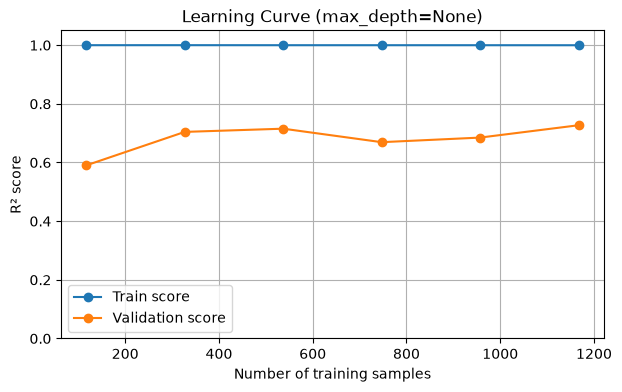

In [5]:
# TODO
# max_depth=None 결정트리의 학습곡선을 그려보세요.

# 1. 깊이를 제한하지 않은 결정트리
tree_deep = DecisionTreeRegressor(max_depth=None, random_state=42)

# 2. 문제 1과 같은 방식으로 학습곡선 계산
train_sizes, train_scores, val_scores = learning_curve(
    tree_deep,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 6)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# 4. 두 곡선 사이 간격 확인
deep_result = pd.DataFrame({
    "train_size": train_sizes,
    "train_score": train_mean,
    "val_score": val_mean,
    "gap": train_mean - val_mean
}).round(3)
display(deep_result)

# 3. 그래프
plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_mean, marker="o", label="Train score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
plt.title("Learning Curve (max_depth=None)")
plt.xlabel("Number of training samples")
plt.ylabel("R² score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

- 학습샘플 수 116 : train R²의 평균 0.99 / validation R²의 평균 0.59  
-> 판단 : 점수차이 0.40  

- 학습샘플 수 327 : train R²의 평균 0.99 / validation R²의 평균 0.70   
-> 판단 : 점수차이 0.29    

- 학습샘플 수 537 : train R²의 평균 0.99 / validation R²의 평균 0.71  
-> 판단 : 점수차이 0.28  

- 학습샘플 수 1,168 : train R²의 평균 0.99 / validation R²의 평균 0.72  
-> 판단 : 점수차이 0.27  
해당 학습 샘플 수를 선택하여 모델링하는 것이 유리

train R² 평균 0.99 : 매우 작은 제곱오차로 맞추고 있다. (극소한 차이까지 맞춤)  

train R²과 validation R²의 차이 0.27 :  
-> train(훈련)의 점수: 0.99점, validation(검증)의 점수: 0.27로 차이가 크다는 것은 과적합의 신호   
-> (R²의 차이가 0.27라고 해서 **27%만큼 validation이 더 틀렸다고 해석하면 안됨**)

해석 : 깊이 제한이 없는 트리 모델의 경우 train R²이 거의 1배에 가깝지만 validation R²은 0.59~ 0.72까지 다양함  
학습량 증가에 다른 validation이 개선의 여지가 보이지만 trian R²과 validation R²의 격차를 줄이지 못해  
과적합 가능성을 보고 다른 평가지표와 그래프 등을 확인해보아야 한다.  

### Q2. `max_depth=None` 모델에서 데이터를 더 추가하는 것이 도움이 될 가능성이 있는 이유는 무엇인가요?

**답변:**  
-> 과적합 상태에서는 모델이 현재 데이터를 지나치게 학습을 한 상태로  
학습데이터가 더 많아지면 현재 학습했던 패턴 외의 다른 패턴들을 학습할 수가 있기 때문에  
train과 validation의 격차가 줄어들 수 있다.

---

# 필수 2. 검증곡선과 train-valid gap으로 최적 복잡도 확인

## 배경

검증곡선은 **모델의 하이퍼파라미터를 바꿔가며 Train score와 Validation score의 변화를 확인하는 그래프**입니다.

이번 문제에서는 결정트리의 `max_depth`를 바꾸어 모델 복잡도를 조절합니다.

## 문제 1. `max_depth` 검증곡선을 만드세요.

### 요구사항

1. 다음 `max_depth` 후보를 사용합니다.

```python
param_range = [1, 2, 3, 4, 5, 8, 12, 20, None]
```

2. `validation_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 각 `max_depth`의 Train score와 Validation score 평균을 계산합니다.
5. `gap = train_mean - valid_mean`을 계산합니다.
6. `max_depth`, `train`, `validation`, `gap`을 DataFrame으로 만듭니다.
7. Train / Validation score를 하나의 그래프에 표시합니다.

### 확인 포인트

- 복잡도가 증가할수록 Train score가 어떻게 변하는가?
- Validation score는 어느 지점까지 좋아지고 이후 어떻게 변하는가?
- train-valid gap은 깊이가 커질수록 어떻게 변하는가?

,max_depth,train,validation,gap
0,1,0.454,0.430,0.025
1,2,0.634,0.602,0.032
2,3,0.734,0.679,0.055
3,4,0.811,0.734,0.078
4,5,0.862,0.756,0.107
5,8,0.948,0.771,0.177
6,12,0.990,0.746,0.244
7,20,1.000,0.735,0.264
8,None,1.000,0.727,0.273


Validation score가 가장 높은 max_depth: 8 (0.771)


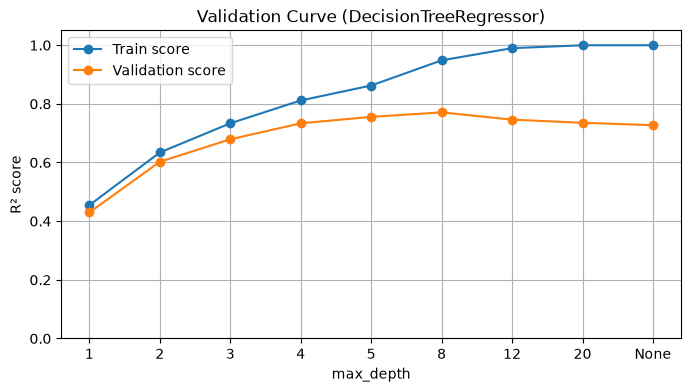

In [6]:
# TODO
# validation_curve()를 이용해 max_depth별 Train / Validation score와 gap을 확인하세요.
param_range = [1, 2, 3, 4, 5, 8, 12, 20, None]

# 2~3. max_depth 후보마다 5-fold 교차검증
train_scores, valid_scores = validation_curve(
    DecisionTreeRegressor(random_state=42),
    X,
    y,
    param_name="max_depth",
    param_range=param_range,
    cv=5
)

# 4~5. 후보별 평균 점수와 gap
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)
gap = train_mean - valid_mean

# 6. 결과 표 (None은 그래프에 쓰려고 문자열로 바꿈)
depth_labels = [str(d) for d in param_range]

vc_result = pd.DataFrame({
    "max_depth": depth_labels,
    "train": train_mean,
    "validation": valid_mean,
    "gap": gap
}).round(3)
display(vc_result)

best_idx = valid_mean.argmax()
print(f"Validation score가 가장 높은 max_depth: {depth_labels[best_idx]} ({valid_mean[best_idx]:.3f})")

# 7. Train / Validation 그래프
x = range(len(param_range))

plt.figure(figsize=(8, 4))
plt.plot(x, train_mean, marker="o", label="Train score")
plt.plot(x, valid_mean, marker="o", label="Validation score")
plt.xticks(x, depth_labels)
plt.title("Validation Curve (DecisionTreeRegressor)")
plt.xlabel("max_depth")
plt.ylabel("R² score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

**[두 곡선의 목적을 구분]**  
- 학습곡선과 검증곡선  
학습곡선 : 학습자료의 수를 바꿈  
검증곡선 : max_depth를 바꿈

- 모델 결과를 유지하려는 핵심 조건  
학습곡선 : 트리 깊이 설정  
검증곡선 : 데이터와 교차검증 분할  

- 학습곡선 메인 질문 : 데이터가 늘어나면 늘어날수록 성능이 어떻게 달라지는가?  

- 검증곡선 메일 질문 : 오차나 변동이 큰 경우 성능이 어떻게 달라지는가?  

| max_depth | train R² 평균 | validation R² 평균 | gap | 진단근거 |
|---|---:|---:|---:|---|
| 1 | 0.454 | 0.430 | 0.025 | 두 점수 모두 상대적으로 낮음 |
| 2 | 0.634 | 0.602 | 0.032 | 깊이 1보다 개선되지만 표현력 제한 |
| 3 | 0.734 | 0.679 | 0.055 | 학습,검증이 함께 상승 |
| 4 | 0.811 | 0.734 | 0.078 | 검증점수가 더 높아짐 |
| 5 | 0.862 | 0.756 | 0.107 | 성능과 복잡도 균형을 검토할 수 있는 후보 |
| **8** | **0.948** | **0.771** | **0.177** | **현재 9개 후보중 검증 평균 최고** |
| 12 | 0.990 | 0.746 | 0.244 | 학습은 개선되나 검증은 하락 |
| 20 | 1.000 | 0.735 | 0.264 | 큰 일반화 차이가 남음 |
| None | 1.000 | 0.727 | 0.273 | 거의 완벽한 학습점수와 큰 gap |

- `max_depth 8을 선택한 이유`  
-> train R²과 validation R²이 비교적 격차가 작으며 validation R²가 가장 높은 후보를 선택  

- `해석` : 복잡도를 높이면 train R²는 계속 상승하지만 validation R²는 깊이 8에서 0.77로 가장 높고 그 이후에 감소,  
깊이 1같은 경우 R²값이 train과 test에서 모두 낮아 과소적합을 의심해볼 수 있으며  
매우 깊은 depth에서는 train R²만 좋아져 과적합의 신호를 포착할 수 있다.  
우선 가장 효과가 좋았던 depth 8을 검토해볼 수 있다.  




### Q3. Validation score가 가장 높은 `max_depth`는 무엇인가요?  

**답변:**  
- max_depth 8이 0.77로 가장 높았다.

- max_depth 1(0.430)부터 8(0.771)까지는 복잡도가 커질수록 Validation score가 올라가지만,  
8 이후로는 12(0.746), 20(0.735), None(0.727)으로 떨어짐  
-> `max_depth=8`이 과소적합과 과적합 사이에서 가장 균형 잡힌 복잡도로 볼 수 있음

### Q4. `max_depth`가 매우 커질수록 train-valid gap이 커지는 이유는 무엇인가요?

**답변:**  
- 결정트리가 깊어질수록 학습 데이터의 세부적인 패턴과 노이즈까지 학습을 하려고 하기 때문에  
train은 지속적으로 높아지지만 새로운 validate는 충분히 적응하지 못하기 때문에 유지되거나 낮아질 수 있다.  

---

# 과제 1. 모델 상태를 진단하고 대응 전략 선택하기

## 배경

필수 실습에서는 학습곡선과 검증곡선을 이용해 모델의 상태를 확인했습니다.

이번 과제에서는 검증곡선 결과를 이용하여 세 가지 복잡도의 모델 상태를 직접 판단합니다.

> 과제는 필수 실습에서 확인한 결과를 해석하는 수준입니다.

## 문제

다음 세 모델을 확인하세요.

- `max_depth=1`
- `max_depth=8`
- `max_depth=None`

### 요구사항

1. 필수 2에서 만든 `gap_df`에서 세 모델의 Train score, Validation score, gap을 확인합니다.
2. 각 모델을 다음 중 하나로 진단합니다.
   - 과소적합
   - 비교적 적절한 복잡도
   - 과적합
3. 각 모델의 진단 근거를 Train score, Validation score, gap을 이용해 설명합니다.
4. 과소적합 또는 과적합 모델에 대해 교안에서 배운 대응 전략 중 적절한 방향을 하나 이상 작성합니다.

### 확인 포인트

- 점수가 낮고 gap이 작은 경우를 과소적합으로 해석할 수 있는가?
- Train score만 매우 높고 gap이 큰 경우를 과적합으로 해석할 수 있는가?
- Validation score가 높고 gap이 지나치게 크지 않은 지점을 적절한 후보로 볼 수 있는가?
- 진단 후에 대응 전략을 선택했는가?

In [7]:
# TODO
# gap_df에서 max_depth=1, 8, None에 해당하는 결과를 확인하세요.
gap_df = vc_result

selected = gap_df[gap_df["max_depth"].isin(["1", "8", "None"])]
display(selected)

,max_depth,train,validation,gap
0,1,0.454,0.430,0.025
5,8,0.948,0.771,0.177
8,None,1.000,0.727,0.273


### Q5. 세 모델의 상태를 각각 진단하세요.

| max_depth | 진단 | 근거 |
|---|---|---|
| 1 | 과소적합 | Train 0.454, Validation 0.430으로 둘 다 낮고 gap은 0.025로 작음 → 모델이 너무 단순해 학습 데이터의 패턴도 충분히 담지 못함 (과소적합) |
| 8 | 비교적 적절한 복잡도 | Validation 0.771로 후보 중 가장 높고, gap 0.177은 None보다 작음 → 성능과 일반화의 균형이 가장 좋은 지점 |
| None | 과적합 | Train 1.000으로 학습 데이터를 거의 외웠지만 Validation은 0.727로 떨어지고 gap은 0.273으로 가장 큼 → 학습 데이터의 우연한 패턴까지 학습함 (과적합) |

### Q6. 과소적합 모델과 과적합 모델에 각각 어떤 대응 전략을 사용할 수 있나요?

**답변:**
- 과소적합(max_depth=1): max_depth를 늘려 모델 복잡도를 높이거나, 집값 예측에 도움이 되는 feature를 추가함  
- 과적합(max_depth=None): max_depth를 제한하거나 min_samples_leaf를 키워 모델을 단순하게 만들고, 학습 데이터를 더 확보함

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 편향이 높은 모델은 일반적으로 과소적합과 과적합 중 어느 상태와 관련이 있나요?  
-> 편향이 높은 모델은 일반적으로 과소적합과 관련이 있다.  

2. 분산이 높은 모델은 일반적으로 어느 상태와 관련이 있나요?  
-> 분산이 높은 모델은 일반적으로 과적합과 관련이 있다.  

3. 학습곡선에서 Train과 Validation이 낮은 값에서 함께 수렴하면 어떤 상태인가요?  
-> 과소적합의 신호  

4. Train score는 매우 높지만 Validation score가 낮고 gap이 크다면 어떤 상태인가요?
-> 과적합의 신호  

5. 검증곡선에서 Validation score가 가장 높은 지점은 어떤 의미를 가지나요?  
-> 현재 후보중에서 새로운 데이터에 대한 성능이 가장 좋은 적절한 모델 후보로 선택할 수 있다.  

6. 과적합과 과소적합을 진단하지 않고 바로 처방하면 안 되는 이유는 무엇인가요?  
-> 과소적합과 과적합은 서로 반대되는 개념  
-> 과소적합 모델은 더 단순하게 설계하거나, 과적합 모델은 더 복잡하게 만들면 문제가 커질 수 있다.  
-> 따라서 어떤 문제를 해결해야하는지 명확하게 알고 대응해야한다.